## Outline
In this notebook, more features will be created from 'Description' and 'Amenities'

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('zameen_new_cleaned_v1.csv',index_col=0)

In [3]:
df.head()

,Real Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
0,"D-12/2, D-12",House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
1,"D-12/1, D-12",House,5.20,4,4.4,3,D-12,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
2,"D-12/4, D-12",House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
3,"D-12/1, D-12",House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
4,"Bahria Enclave - Sector H, Bahria Enclave",House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 6456 entries, 0 to 6482
Data columns (total 15 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6456 non-null   str    
 1   Type                                              6456 non-null   str    
 2   Price(Cr)                                         6456 non-null   float64
 3   Bath(s)                                           6456 non-null   str    
 4   Area(Marla)                                       6456 non-null   float64
 5   Bedroom(s)                                        6456 non-null   str    
 6   Location                                          6456 non-null   str    
 7   Description                                       6456 non-null   str    
 8   Amenities: Main Features                          5997 non-null   str    
 9   Amenities: Rooms                   

In [5]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       6473, 6474, 6475, 6476, 6477, 6478, 6479, 6480, 6481, 6482],
      dtype='int64', length=6456)

In [6]:
df.duplicated().sum()

np.int64(97)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 15 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6359 non-null   str    
 1   Type                                              6359 non-null   str    
 2   Price(Cr)                                         6359 non-null   float64
 3   Bath(s)                                           6359 non-null   str    
 4   Area(Marla)                                       6359 non-null   float64
 5   Bedroom(s)                                        6359 non-null   str    
 6   Location                                          6359 non-null   str    
 7   Description                                       6359 non-null   str    
 8   Amenities: Main Features                          5907 non-null   str    
 9   Amenities: Rooms                   

## Real Location

Real Location has the following structure **{Location with Phase/Sector/Block} , {Location}**

- Make two columns Real Location and SubLocation
- After coma
- e.g DHA Phase (number) & Sector (alphabet or whatever) 

In [9]:
df['Real Location'].value_counts()

Real Location
DHA Defence Phase 2, DHA Defence              348
Bani Gala, Islamabad                          235
G-13, Islamabad                               210
D-12, Islamabad                               132
B-17, Islamabad                               123
                                             ... 
Park One, F-10/3                                1
Engineers Co-operative Housing, D-18            1
Bahria Enclave - Sector B2, Bahria Enclave      1
Gulberg Greens - Block D, Gulberg Greens        1
Alipur Farash, Islamabad                        1
Name: count, Length: 518, dtype: int64

In [10]:
df['Main Location'] = df['Real Location'].str.split(',').str.get(1)

In [11]:
df['Real Location'] = df['Real Location'].str.split(',').str.get(0)

In [12]:
df['Main Location'].value_counts()

Main Location
Islamabad                         2260
DHA Defence                        440
Bahria Enclave                     308
MPCHS - Multi Gardens              237
DHA Defence Phase 2                214
                                  ... 
E-11/2                               1
Ghauri Town Phase 7                  1
Engineers Co-operative Housing       1
F-10/3                               1
D-18                                 1
Name: count, Length: 130, dtype: int64

In [13]:
# Replacing the value of Main Location with Location where Main Location == "Islamabad"
df.loc[df["Main Location"]==" Islamabad",'Main Location'] =  df['Location']

In [14]:
df['Main Location'] = df['Main Location'].str.strip()

In [15]:
with pd.option_context('display.max_rows', None):
    print(df[df['Type'] == 'Flat']['Main Location'].value_counts().sort_index())


Main Location
Al-Ghurair Giga                               20
B-17                                          87
Bahria Enclave                                70
Bahria Town                                   30
Bani Gala                                     14
Bhara kahu                                     2
Blue Area                                     15
CBR Town                                       3
CBR Town Phase 1                               2
Canyon Views Cvrp                              2
Chak Shahzad                                   1
Constitution Avenue                            8
D-12                                           3
D-17                                          33
DHA Defence                                   44
DHA Defence Phase 1                            9
DHA Defence Phase 2                          124
DHA Defence Phase 4                            1
DHA Defence Phase 5                           29
DHA Phase 5 - Sector H                        29
Diplom

In [16]:
with pd.option_context('display.max_rows', None):
    print(df['Real Location'].value_counts())

Real Location
DHA Defence Phase 2                                                348
Bani Gala                                                          235
G-13                                                               210
D-12                                                               132
B-17                                                               123
Top City 1                                                         122
F-8                                                                113
Bahria Enclave                                                     103
F-7                                                                 85
Faisal Town - F-18                                                  81
MPCHS - Block F                                                     80
MPCHS - Multi Gardens                                               79
F-6                                                                 71
G-11                                                           

In [17]:
with pd.option_context('display.max_rows', None):
    print(df['Main Location'].value_counts().sort_index())

Main Location
Airport Enclave                                6
Airport Green Garden                           4
Al Qaim Town                                   1
Al-Ghurair Giga                               20
Alipur Farash                                  1
Arsalan Town                                   4
B-17                                         279
Bahria Enclave                               308
Bahria Garden City                             8
Bahria Garden City - Zone 4                    1
Bahria Town                                  111
Bani Gala                                    240
Bhara kahu                                    21
Blue Area                                     18
British Homes Colony                           1
Burma Town                                     4
C-18                                           1
CBR Town                                      14
CBR Town Phase 1                              27
Canyon Views Cvrp                              2
Chak S

In [18]:
# DHA , FECHS, Gulberg

In [19]:
df.loc[df['Main Location']=='DHA Serene City','Main Location'] = 'DHA Phase 3'

In [20]:
df.loc[df['Main Location'].str.contains('G-11'),'Main Location'] = 'G-11'

In [21]:
df.loc[df['Main Location']=='Top City 1 - Block B','Main Location'] = 'Top City 1'

In [22]:
df.loc[df['Main Location']=='National Police Foundation','Main Location'] = 'National Police Foundation O-9'

In [23]:
df.loc[df['Main Location'].str.contains('G-15'),'Main Location'] = 'G-15'

In [24]:
df['Main Location'] = df['Main Location'].str.replace('Markaz','')
df['Main Location'] = df['Main Location'].str.strip()

In [25]:
df.loc[df['Main Location'].str.contains('E-16'),'Main Location'] = 'E-16'
df.loc[df['Main Location'].str.contains('F-10'),'Main Location'] = 'F-10'

In [26]:
df.loc[df['Main Location']=='Bahria Garden City - Zone 4','Main Location'] = 'Bahria Garden City'

In [27]:
df.loc[df['Main Location']=='DHA Defence','Main Location'] = df['Real Location']

In [28]:
df.loc[df['Main Location']=='Gulberg',"Main Location"] = df['Real Location']

In [29]:
df.loc[df['Main Location'].str.contains("DHA Valley"),'Main Location'] = 'DHA Valley'

In [30]:
df.loc[df['Main Location']=='DHA Phase 5 - Sector H','Main Location'] = 'DHA Defence Phase 5'

In [31]:
df.loc[df['Main Location']=='DHA Phase 1 - Sector F','Main Location'] = 'DHA Defence Phase 1'

In [32]:
df.loc[df['Main Location']=='Faisal Town - F-18','Main Location'] = 'Faisal Town Phase 1'

In [33]:
df.loc[df['Main Location']=='CBR Town','Main Location'] = 'CBR Town Phase 1'

In [34]:
df.loc[df['Main Location']=='G-11/3','Main Location'] = 'G-11'

In [35]:
df.loc[df['Main Location']=='Gulshan-e-Sehat 1','Main Location'] = 'E-18' 

In [36]:
df.loc[df['Main Location']=='Gulshan-e-Sehat 2','Main Location'] = 'E-18'

In [37]:
df.loc[df['Main Location'].str.contains('E-11'),'Main Location'] = 'E-11'
df.loc[df['Main Location']=='F-11/1','Main Location'] = 'F-11'

In [38]:
df.loc[df['Main Location'].str.contains('Gulberg Greens'),'Main Location'] = 'Gulberg Greens'

In [39]:
df.loc[df['Main Location'].str.contains('Ghauri'),'Main Location'] = "Ghauri Town"

In [40]:
df.loc[df['Main Location']=='Gulberg Business Square','Main Location'] = 'Gulberg Greens'

In [41]:
df.loc[df['Main Location']=='Gulberg Residencia - Block D','Main Location'] = 'Gulberg Residencia'

In [42]:
df.loc[df['Main Location']=='F-11 Markaz','Main Location'] = 'F-11'

In [43]:
df.loc[df['Main Location']=='Bahria Garden City - Zone 4','Main Location'] = 'Bahria Garden City'
df.loc[df['Main Location']=='Islamabad - Murree Expressway','Main Location'] = 'Murree Expressway' 

In [44]:
df['Main Location'] = df['Main Location'].str.replace("Defence ",'')

*Main Location Done* 

In [45]:
# Where Real Location is the same as Main Location
df[df['Real Location'] == df['Main Location']].shape

(2291, 16)

In [46]:
with pd.option_context('display.max_rows', None):
    print(df[df['Real Location'] != df['Main Location']]['Real Location'].value_counts())

Real Location
DHA Defence Phase 2                                                348
Bahria Enclave                                                     103
Faisal Town - F-18                                                  81
MPCHS - Block F                                                     80
MPCHS - Multi Gardens                                               79
Faisal Margalla City                                                64
Bahria Enclave - Sector N                                           62
Jinnah Gardens                                                      59
Bahria Enclave - Sector C1                                          56
Jinnah Gardens Phase 1                                              54
The Centaurus                                                       53
Eighteen                                                            52
DHA Defence Phase 5                                                 49
G-13/1                                                         

In the below code we are extracting :
- Location (Just like Main Location) --> Going to use it to extract the Building names for FLATS

In [47]:
import pandas as pd
import re

# Assuming your data is loaded into a variable named 'housing_data'
# and the column is named 'Real Location'

def extract_location_details(location_string):
    # Handle missing or empty values gracefully
    if pd.isna(location_string):
        return pd.Series("Unknown")
        
    location_string = str(location_string).strip()
    
    main_loc = location_string
    
    # 1. Check for the Hyphen pattern (e.g., "Top City 1 - Block A")
    if " - " in location_string:
        parts = location_string.split(" - ", 1) # Split only on the first occurrence
        main_loc = parts[0].strip()
        
    # 2. Check for the Slash pattern (CDA Sectors like "D-12/4" or "G-13/2")
    # This regex looks for a letter, a hyphen, numbers, a slash, and more numbers
    elif re.search(r'([A-Za-z]-\d{1,2})/(\d{1,2})', location_string):
        match = re.search(r'([A-Za-z]-\d{1,2})/(\d{1,2})', location_string)
        main_loc = match.group(1) # Extracts "D-12"
        
    return pd.Series(main_loc)

# Apply the function to create two brand new columns
df['Main Location - Copy'] = df['Real Location'].apply(extract_location_details)

In [48]:
df[['Real Location', 'Main Location - Copy']].sample(50)

,Real Location,Main Location - Copy
4212,D-12,D-12
1320,Soan Garden,Soan Garden
1909,Askari Tower 4,Askari Tower 4
1938,MPCHS - Multi Gardens,MPCHS
5454,Sofia Sapphire,Sofia Sapphire
3541,Robinas Luxury Residences,Robinas Luxury Residences
3204,DHA Defence Phase 2,DHA Defence Phase 2
4039,MPCHS - Block F,MPCHS
3817,D-17,D-17
2077,Bani Gala,Bani Gala


In [49]:
df['Main Location - Copy'] = df['Main Location - Copy'].str.strip()

In [50]:
with pd.option_context('display.max_rows', None):
    print(df['Main Location - Copy'].value_counts().sort_index())

Main Location - Copy
11 Central Apartments                  6
18 West Residencia                     1
AJ Towers                              3
Abdullah Town                          1
Airport Enclave                        4
Airport Enclave B                      1
Airport Enclave E                      1
Airport Green Garden                   5
Akas Mall & Residencia                 1
Al Qaim Town                           1
Al-Ghurair Giga                       25
Al-Safa Heights                        9
Alipur Farash                          1
Apollo Towers                          1
Aries Tower                            1
Arsalan Town                           4
Aryan Enclave                          1
Askari Heights 4                      32
Askari Tower 1                        16
Askari Tower 2                         9
Askari Tower 3                        15
Askari Tower 4                        13
B-17                                 123
Bahria Enclave                      

In [51]:
df.loc[df['Main Location - Copy'].str.contains('Airport Enclave'),'Main Location - Copy'] = 'Airport Enclave'

In [52]:
df.loc[df['Main Location - Copy']=='Bahria Garden City West','Main Location - Copy'] = 'Bahria Garden City'

In [53]:
df['Main Location - Copy'] = df['Main Location - Copy'].str.replace({"Markaz":'',"Defence ":""})

In [54]:
df['Main Location - Copy'] = df['Main Location - Copy'].str.replace("DHA Homes","DHA Valley")

In [55]:
df.loc[df['Main Location - Copy'].str.contains('Ghauri'),'Main Location - Copy'] = 'Ghauri Town'

In [56]:
df.loc[df['Main Location - Copy'].str.contains('Park View'),'Main Location - Copy'] = 'Park View City'

In [57]:
df.loc[df['Main Location - Copy'].str.contains('PWD'),'Main Location - Copy'] = 'PWD Housing Scheme'

In [58]:
with pd.option_context('display.max_rows', None):
    print(df[df['Type'] == 'Flat']['Main Location'].value_counts().sort_index())

Main Location
Al-Ghurair Giga                               20
B-17                                          87
Bahria Enclave                                70
Bahria Town                                   30
Bani Gala                                     14
Bhara kahu                                     2
Blue Area                                     15
CBR Town Phase 1                               5
Canyon Views Cvrp                              2
Chak Shahzad                                   1
Constitution Avenue                            8
D-12                                           3
D-17                                          33
DHA Defence                                    1
DHA Phase 1                                   19
DHA Phase 2                                  146
DHA Phase 3                                    3
DHA Phase 4                                    2
DHA Phase 5                                   65
Diplomatic Enclave                            34
E-11  

In [59]:
with pd.option_context('display.max_rows', None):
    print(df[df['Type'] == 'Flat']['Main Location - Copy'].value_counts().sort_index())

Main Location - Copy
11 Central Apartments                 6
18 West Residencia                    1
AJ Towers                             3
Akas Mall & Residencia                1
Al-Ghurair Giga                      24
Al-Safa Heights                       8
Apollo Towers                         1
Aries Tower                           1
Askari Heights 4                     29
Askari Tower 1                       16
Askari Tower 2                        9
Askari Tower 3                       15
Askari Tower 4                       13
B-17                                 46
Bahria Enclave                       52
Bahria Garden City                    2
Bahria Town                           1
Bani Gala                            10
Bhara kahu                            1
Blue Area                             4
Bright Hills                          1
Business Bay DHA                      2
CBR Town                              1
CBR Town Phase 1                      4
Capital Heights    

*For Flats, 'Main Location - Copy' tells the Building Details, so renaming it to 'Building' for Flats*

In [60]:
df.rename(columns={'Main Location - Copy':'Building'},inplace=True)

In [61]:
df['Building'].value_counts()

Building
DHA Phase 2                       438
Bahria Enclave                    366
G-13                              330
MPCHS                             316
Bani Gala                         235
                                 ... 
Hamdan Heights                      1
Engineers Coop Housing              1
Park One                            1
Engineers Co-operative Housing      1
Alipur Farash                       1
Name: count, Length: 272, dtype: int64

In [72]:
# Setting to 'Unkown' where there the property is not Flat or Penthouse
df.loc[~df['Type'].isin(['Flat','Penthouse']),'Building'] = 'Unknown'

In [76]:
df['Building'] = df['Building'].str.strip()
df['Main Location'] = df['Main Location'].str.strip()

In [79]:
df[df['Building']!=df['Main Location']]['Building'].value_counts().tail(50)

Building
Capital Heights                      2
PHAF Officers Residencia             2
Zara Heights                         2
Telegardens (T&T ECHS)               2
Park Avenue                          2
Grand Orchard                        2
Islamabad                            2
Minara Residence                     2
Whispering Pines                     2
Islamabad Heights                    2
Gulberg Icon 2                       2
Margalla Hills-2                     2
Hyde Park One                        2
Bahria Garden City                   2
Savoy Residence                      2
Gulberg Emporium Mall & Residency    2
Business Bay DHA                     2
Capital Homes                        1
Karakoram Enclave 2                  1
18 West Residencia                   1
Elanza Mall & Residency              1
Aries Tower                          1
Meher Apartments                     1
Gevora International Hotel & Mall    1
Veranda Executive                    1
Deans Apartments

In [80]:
df.loc[df['Building']=='Bahria Enclave','Main Location'] = 'Bahria Enclave'

## Description

**How to extract**
$$- Dimensions: The word 'Size' is mentioned before, also in () after [Kanal/marla]$$
- Location Details: Different Types (Sectors,City,Town). [Name] 'City', [Alphabet] - [Number]/[Number] , [Town Name] Phase [Phase Number], also 'Sector' is misspelled as 'Sec', also Location is written like this 'For sale in [Location]'
- IsPrimeLocation: The words 'Prime' or 'Prime Location is mentioned'
- SolarPanelAvailable: The word 'Solar' or 'Solar Panel' is mentioned. Spelling mistake 'Sollar'.
- Storey unit --> 1 or 2 or 3. There are spelling mistakes in Storey and unit, unite, Story, also 'First Floor' or '1st Floor' is mentioned, there is a data point where someone wrote 'two point five story' meaning 2.5 .
- BalconyAvailable --> [Adjective] Balcony
- CornerHouse --> True or False , Sometimes only 'Corner' is mentioned. And somewhere 'Second to Corner Location' is used.
- WaterBoreAvailable --> 'Water Boring' or 'Water Bore'

In [80]:
# Is Prime Location

In [81]:
df['Description'].str.lower().str.contains('prime location').value_counts()

Description
False    5029
True     1330
Name: count, dtype: int64

In [82]:
df['IsPrimeLoc'] = df['Description'].str.lower().str.contains('prime location')

In [83]:
df['IsPrimeLoc'].head()

0    False
1    False
2    False
3     True
4    False
Name: IsPrimeLoc, dtype: bool

In [84]:
df['Description'].loc[3]

'5 Marla Double Unit Front-Open 50 ft street House for Sale in CDA Sector D-12/1, Islamabad Discover this beautiful front-open 5 Marla double unit house in the prestigious CDA Sector D-12/1, offering an unobstructed open view and a prime location. This well-designed home features: 5 spacious bedrooms with attached bathrooms Elegant drawing room and comfortable lounge 2 fully equipped kitchens Servant quarter for added convenience 1 car parking space Complete utility connections: gas, electricity, and water bore The property is currently rented out for Rs. 160,000 per month, making it an excellent investment opportunity as well as a perfect family home. Demand: Rs. 5,75,00,000 Location: CDA Sector D-12/1, Islamabad Experience modern living in a serene environment with a clear, open viewideal for those who value comfort, style,'

In [85]:
# Solar Panel

In [86]:
df['Description'].str.lower().str.contains('solar').value_counts()

Description
False    6169
True      190
Name: count, dtype: int64

In [87]:
df['Description'].str.lower().str.contains('soller')[df['Description'].str.lower().str.contains('soller') == True]

14      True
2499    True
4570    True
Name: Description, dtype: bool

In [88]:
df['Description'].loc[14]

'Jinah Garden 7 Marla Lop Clear House For Sale Upper Portion Is Fully Furnished Soller Install Reasonable Price Ground Floor rent Out 50 K'

In [89]:
import pandas as pd

# Sample data with your misspellings and some negative cases
data = {
    'Description': [
        "House with a 10kW solar panel installed.",
        "Beautiful sollar system included.",
        "Brand new soler heating.",
        "Has a soller backup.",
        "No electricity backup available.",
        "Solid wood doors and absolute luxury." # 'sol' is here, but shouldn't match
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# \b       : Word boundary (ensures we don't accidentally match "solid" or "consoler")
# sol      : Exactly "sol"
# l?       : An optional 'l' (catches single 'l' or double 'll')
# [ae]     : Either an 'a' or an 'e'
# r        : Exactly 'r'
# \b       : Word boundary 

solar_pattern = r'\bsoll?[ae]r\b'

# --- APPLYING IT ---
# .str.contains() returns True if the pattern is found, and False if it isn't.
# case=False makes it case-insensitive (matches Solar, SOLAR, soler, etc.)
# na=False ensures empty rows return False instead of an error.

temp['SolarPanelAvailable'] = temp['Description'].str.contains(solar_pattern, case=False, na=False)

(temp[['Description', 'SolarPanelAvailable']])

,Description,SolarPanelAvailable
0,House with a 10kW solar panel installed.,True
1,Beautiful sollar system included.,True
2,Brand new soler heating.,True
3,Has a soller backup.,True
4,No electricity backup available.,False
5,Solid wood doors and absolute luxury.,False


In [90]:
df['SolarInstalled'] =  df['Description'].str.contains(solar_pattern,case=False)

In [91]:
df['SolarInstalled'].value_counts()

SolarInstalled
False    6154
True      205
Name: count, dtype: int64

In [92]:
# Water Boring

In [93]:
import pandas as pd

# Sample data covering standard terms, misspellings, and reversed word orders
data = {
    'Description': [
        "House with a fresh water bore.",
        "Complete water boring is done.",
        "Has watter borring installed.",       # Misspelled both words
        "24/7 watar boreing available.",       # Misspelled both words
        "Only bore water is available here.",  # Reversed order
        "Beautiful corner house, solid wood."  # No match
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# 1. w[ae]tt?[ae]r : Catches water, watter, watar, weter
# 2. bor(?:e|ing|ring|eing) : Catches bore, boring, borring, boreing
# 3. We use the OR operator (|) to check for "water bore" OR "bore water"

water_word = r'w[ae]tt?[ae]r'
bore_word = r'bor(?:e|ing|ring|eing)'

# Combine them to catch both "[Water] [Bore]" and "[Bore] [Water]"
regex_pattern = rf'(?i)\b(?:{water_word}\s+{bore_word}|{bore_word}\s+{water_word})\b'

# --- APPLYING IT ---
# Returns True if any variation is found, False if not
temp['WaterBoreAvailable'] = temp['Description'].str.contains(regex_pattern, na=False)

(temp[['Description', 'WaterBoreAvailable']])

,Description,WaterBoreAvailable
0,House with a fresh water bore.,True
1,Complete water boring is done.,True
2,Has watter borring installed.,True
3,24/7 watar boreing available.,True
4,Only bore water is available here.,True
5,"Beautiful corner house, solid wood.",False


In [94]:
df['Description'].str.contains(regex_pattern,na=False).value_counts()

Description
False    5715
True      644
Name: count, dtype: int64

In [95]:
df['WaterBore'] = df['Description'].str.contains(regex_pattern,na=False)

In [96]:
# Corner House

In [97]:
 import pandas as pd

# Sample data including real corner houses and the "sneaky" broker phrases
data = {
    'Description': [
        "Beautiful corner house for sale.",
        "This is a second to corner location.",   # Sneaky broker!
        "Park face corner available.",
        "Next to corner plot.",                  # Sneaky broker!
        "Situated near corner.",                 # Sneaky broker!
        "House is 2nd to corner.",               # Sneaky broker!
        "Generic house in the middle of street." # Standard negative
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# (?i) : Makes it case-insensitive so it catches "Corner", "CORNER", etc.
# (?<!...) : These are Negative Lookbehinds. They act as bouncers.
# \bcorner\b : The actual target word we are looking for.

regex_pattern = r'(?i)(?<!\bsecond to )(?<!\b2nd to )(?<!\bnext to )(?<!\bnear )(?<!\bclose to )\bcorner\b'

# --- APPLYING IT ---
# Returns True only if 'corner' is found WITHOUT the banned phrases preceding it
temp['CornerHouse'] = temp['Description'].str.contains(regex_pattern, na=False)

(temp[['Description', 'CornerHouse']])

,Description,CornerHouse
0,Beautiful corner house for sale.,True
1,This is a second to corner location.,False
2,Park face corner available.,True
3,Next to corner plot.,False
4,Situated near corner.,False
5,House is 2nd to corner.,False
6,Generic house in the middle of street.,False


In [98]:
df['Description'].str.contains(regex_pattern, na=False).value_counts()

Description
False    5745
True      614
Name: count, dtype: int64

In [99]:
df['CornerHouse'] =  df['Description'].str.contains(regex_pattern, na=False)

## Amenities: Main Features

*What to do*
1. Extract: Parking Spaces, No.of Floors, Built in Year
2. Perform clustering on the rest of Amenities to check whether they are correlating or not.
3. Else perform some kind of luxury score based on these features

In [100]:
df.dropna(how='all',subset=['Amenities: Rooms','Amenities: Main Features']).shape

(6009, 21)

In [101]:
df[df[['Amenities: Rooms','Amenities: Main Features','Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities']].isnull().all(axis=1)].shape

(137, 21)

In [102]:
df['Amenities: Main Features'].isnull().sum()

np.int64(452)

In [103]:
df['Amenities: Main Features'].str.contains('Floors').value_counts()

Amenities: Main Features
True     4549
False    1810
Name: count, dtype: int64

In [104]:
df['Amenities: Main Features'].loc[2]

'Built in year, Parking Spaces: 1, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features'

In [105]:
df['Amenities: Main Features'].str.split(',').str.len().sort_values(ascending=False).head()

6481    15.0
6457    15.0
6453    15.0
50      15.0
6476    15.0
Name: Amenities: Main Features, dtype: float64

In [106]:
df['Amenities: Main Features'].loc[1325]

'Built in year: 2025, Parking Spaces, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor, Floors in Building, Elevators, Service Elevators in Building, Other Main Features, Furnished'

In [107]:
set(df['Amenities: Main Features'].dropna().str.replace(', ',',').str.split(',').sum())

{'Built in year',
 'Built in year: 0000',
 'Built in year: 05',
 'Built in year: 06',
 'Built in year: 1',
 'Built in year: 10',
 'Built in year: 12',
 'Built in year: 122024',
 'Built in year: 15',
 'Built in year: 18',
 'Built in year: 1887',
 'Built in year: 1889',
 'Built in year: 1898',
 'Built in year: 1970',
 'Built in year: 1978',
 'Built in year: 1980',
 'Built in year: 1981',
 'Built in year: 1982',
 'Built in year: 1984',
 'Built in year: 1985',
 'Built in year: 1987',
 'Built in year: 1988',
 'Built in year: 1990',
 'Built in year: 1992',
 'Built in year: 1995',
 'Built in year: 1997',
 'Built in year: 1998',
 'Built in year: 1999',
 'Built in year: 2',
 'Built in year: 20',
 'Built in year: 2000',
 'Built in year: 20000',
 'Built in year: 20001',
 'Built in year: 2001',
 'Built in year: 2002',
 'Built in year: 2003',
 'Built in year: 2004',
 'Built in year: 2005',
 'Built in year: 2006',
 'Built in year: 2007',
 'Built in year: 2008',
 'Built in year: 2009',
 'Built in yea

In [108]:
import pandas as pd
import numpy as np
import re

# 1. Sample data including the tricky decimals and plus signs
data = {
    'ID': [2110, 1549, 3035],
    'Features': [
        'Parking Spaces: 3+, Floors: 1.5, Double Glazed Windows, Central Air Conditioning',
        'Parking Spaces: +30, Floors: 2.5, Electricity Backup',
        'Parking Spaces: 2, Floors: 2, Waste Disposal'
    ]
}
temp = pd.DataFrame(data)

# 2. The updated extraction function
def extract_amenities(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        if not item:
            continue
            
        # --- THE NEW REGEX ---
        # Group 1 (.*?): Captures the amenity name
        # Separator: Looks for a colon or space
        # Group 2 (\+?\d+(?:\.\d+)?\+?): Captures numbers, decimals, and optional '+' signs
        match = re.search(r'^(.*?)(?:\s*:\s*|\s+)(\+?\d+(?:\.\d+)?\+?)$', item)
        
        if match:
            feature_name = match.group(1).strip()
            raw_value = match.group(2).strip() # This could be '1.5', '3+', or '+30'
            
            # Check if a '+' sign is present anywhere in the extracted number
            has_plus = '+' in raw_value
            
            # Strip out the '+' so Python can convert the string into a mathematical float
            clean_val = float(raw_value.replace('+', ''))
            
            # If there was a '+', add 1 to the number (turning 3+ into 4)
            if has_plus:
                clean_val += 1
                
            # Keep it clean: If it's a whole number (like 4.0), make it an integer (4). 
            # If it has a decimal (like 1.5), keep it as a float.
            if clean_val.is_integer():
                amenity_dict[feature_name] = int(clean_val)
            else:
                amenity_dict[feature_name] = clean_val
                
        else:
            # If it's just text (like 'Double Glazed Windows'), assign 1
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function and build the grid
parsed_amenities = temp['Features'].apply(extract_amenities)
grid_temp = pd.DataFrame(parsed_amenities.tolist())

# 4. Fill missing values with 0
# REMOVED: grid_temp = grid_temp.fillna(0) 
# By not using fillna(), Pandas will naturally leave the missing values as NaN.

# 5. Attach the IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Parking Spaces,Floors,Double Glazed Windows,Central Air Conditioning,Electricity Backup,Waste Disposal
0,2110,4,1.5,1.0,1.0,NaN,NaN
1,1549,31,2.5,NaN,NaN,1.0,NaN
2,3035,2,2.0,NaN,NaN,NaN,1.0


In [109]:
parsed_amenities = df['Amenities: Main Features'].str.replace('Floors','Floor').apply(extract_amenities)

parsed_amenities.head()

0    {'Built in year': 1, 'Parking Spaces': 4, 'Dou...
1    {'Built in year': 1, 'Parking Spaces': 3, 'Dou...
2    {'Built in year': 1, 'Parking Spaces': 1, 'Dou...
3    {'Built in year': 4, 'Parking Spaces': 2, 'Dou...
4    {'Built in year': 2025, 'Parking Spaces': 1, '...
Name: Amenities: Main Features, dtype: object

In [110]:
parsed_amenities.head().tolist()

[{'Built in year': 1,
  'Parking Spaces': 4,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1},
 {'Built in year': 1,
  'Parking Spaces': 3,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1},
 {'Built in year': 1,
  'Parking Spaces': 1,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1},
 {'Built in year': 4,
  'Parking Spaces': 2,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1,
  'Furnished': 1},
 {'Built in ye

In [111]:
main_amenities = pd.DataFrame(parsed_amenities.tolist(),index=df.index)

In [112]:
main_amenities.shape

(6359, 18)

In [113]:
main_amenities.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Built in year                  5197 non-null   float64
 1   Parking Spaces                 5509 non-null   float64
 2   Double Glazed Windows          5132 non-null   float64
 3   Central Air Conditioning       4801 non-null   float64
 4   Central Heating                4708 non-null   float64
 5   Flooring                       5654 non-null   float64
 6   Electricity Backup             5216 non-null   float64
 7   Waste Disposal                 5099 non-null   float64
 8   Floor                          4549 non-null   float64
 9   Other Main Features            4494 non-null   float64
 10  Furnished                      3339 non-null   float64
 11  Lobby in Building              1245 non-null   float64
 12  Service Elevators in Building  1093 non-null   float64
 13  Floo

In [114]:
main_amenities.sample(5)

,Built in year,Parking Spaces,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Other Main Features,Furnished,Lobby in Building,Service Elevators in Building,Floor in Building,Elevators,Parking Spaces: -2,Floor in Building: -7,Elevators: -2
429,2025.0,1.0,1.0,NaN,NaN,1.0,NaN,1.0,2.0,NaN,NaN,1.0,NaN,9.0,4.0,NaN,NaN,NaN
1528,2025.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3586,2025.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5807,2024.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
nonempty_idx = main_amenities.sum(axis=1)[main_amenities.sum(axis=1)!=0].index
nonempty_idx.shape

(5907,)

In [116]:
# main_amenities_copy = main_amenities.loc[nonempty_idx].copy()
main_amenities_copy = main_amenities.copy().fillna(0)

In [117]:
main_amenities.shape

(6359, 18)

In [118]:
main_amenities_copy.shape

(6359, 18)

In [119]:
main_amenities_copy.drop(columns=['Built in year','Other Main Features','Lobby in Building','Floor in Building','Elevators','Service Elevators in Building','Floor','Parking Spaces'],inplace=True)

In [120]:
main_amenities_copy.head()

,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Furnished,Parking Spaces: -2,Floor in Building: -7,Elevators: -2
0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0


In [121]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [122]:
scalar = StandardScaler()

transformed_amenities = scalar.fit_transform(main_amenities_copy)

In [123]:
wcs_reduced = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(transformed_amenities)
    wcs_reduced.append(kmeans.inertia_)

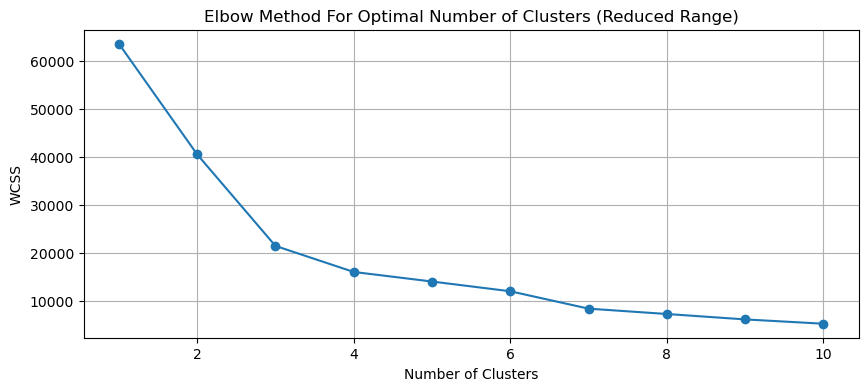

In [124]:
plt.figure(figsize=(10,4))
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.plot(range(1,11),wcs_reduced,marker='o',linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True);

In [141]:
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(transformed_amenities)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(transformed_amenities)

In [142]:
cluster_assignments

array([0, 0, 0, ..., 0, 0, 0], shape=(6359,), dtype=int32)

In [143]:
df['luxury_type'] = cluster_assignments

In [148]:
with pd.option_context('display.max_colwidth', None):
    display(df[['Amenities: Main Features','luxury_type']].sample(10)) 

,Amenities: Main Features,luxury_type
2857,"Built in year: 2025, Parking Spaces: 1, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Other Main Features, Furnished",0
3895,"Built in year: 2001, Parking Spaces: 1, Double Glazed Windows, Flooring, Electricity Backup, Waste Disposal, Other Main Features",0
2228,"Built in year: 2025, Parking Spaces, Flooring, Waste Disposal, Floors: 2, Other Main Features",1
3361,"Built in year: 2024, Parking Spaces, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor, Other Main Features, Furnished",0
2627,"Built in year: 2027, Parking Spaces, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor: 2, Floors in Building: 3, Service Elevators in Building, Other Main Features",0
1559,"Parking Spaces: 2, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Other Main Features",0
3377,"Waste Disposal, Other Main Features",1
3060,"Built in year: 2023, Parking Spaces, Lobby in Building, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor, Floors in Building, Elevators: 5, Service Elevators in Building, Other Main Features, Furnished",0
1225,"Built in year: 2024, Parking Spaces: 2, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features",0
2435,"Built in year: 2025, Parking Spaces: 2, Double Glazed Windows, Central Heating, Flooring, Waste Disposal, Floors: 2",0


**From Observation:**
- **0 --> Luxury**
- **1 --> Budget**

In [149]:
df['luxury_type'].value_counts()

luxury_type
0    5032
1    1327
Name: count, dtype: int64

In [150]:
main_amenities.head()

,Built in year,Parking Spaces,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Other Main Features,Furnished,Lobby in Building,Service Elevators in Building,Floor in Building,Elevators,Parking Spaces: -2,Floor in Building: -7,Elevators: -2
0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Appending the columns to original dataframe <i>'Built in year','Parking Spaces','Floor','Lobby in Building','Elevators','Service Elevators in Building','Floor in Building' </i>

In [151]:
df = pd.concat((df,main_amenities[['Built in year','Parking Spaces','Floor','Lobby in Building','Elevators','Service Elevators in Building','Floor in Building']]),axis=1)

In [152]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6359 non-null   object 
 1   Type                                              6359 non-null   str    
 2   Price(Cr)                                         6359 non-null   float64
 3   Bath(s)                                           6359 non-null   str    
 4   Area(Marla)                                       6359 non-null   float64
 5   Bedroom(s)                                        6359 non-null   str    
 6   Location                                          6359 non-null   str    
 7   Description                                       6359 non-null   str    
 8   Amenities: Main Features                          5907 non-null   str    
 9   Amenities: Rooms                   

## Amenities: Rooms

In [153]:
df['Amenities: Rooms'].loc[0]

'Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2, Drawing Room, Dining Room, Kitchens: 2, Study Room, Prayer Room, Powder Room, Gym, Store Rooms: 1, Steam Room, Lounge or Sitting Room, Laundry Room, Other Rooms'

In [154]:
def extract_rooms(series):
    if pd.isna(series):
        return {}
    
    rooms_dic = {}

    room_lst = series.split(',')

    for room in room_lst:
        room.replace(' ','')
        colon_pos = room.find(':')
        if colon_pos == -1:
            room_name = room.strip()
            room_no = 0
        else:
            room_name = room[:colon_pos]
            room_no = room[colon_pos+1:]
            room_no = float(room_no.strip())

        rooms_dic[room_name] = room_no

    return rooms_dic

In [155]:
parsed_rooms = df['Amenities: Rooms'].str.replace(', ',',').apply(extract_rooms)

In [156]:
rooms = pd.DataFrame(parsed_rooms.tolist(),index=df.index)

In [157]:
rooms.describe()

,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Gym,Store Rooms,Steam Room,Lounge or Sitting Room,Laundry Room,Other Rooms
count,5474.000000,5482.000000,4664.000000,5434.0,5353.0,5467.000000,4561.0,4482.0,4658.0,3853.0,4549.000000,4095.0,5130.0,4832.0,3879.0
mean,4.186153,4.768789,1.121141,0.0,0.0,1.547101,0.0,0.0,0.0,0.0,1.059574,0.0,0.0,0.0,0.0
std,2.315011,4.818550,0.799763,0.0,0.0,0.932267,0.0,0.0,0.0,0.0,0.671845,0.0,0.0,0.0,0.0
min,0.000000,0.000000,-1.000000,0.0,0.0,-1.000000,0.0,0.0,0.0,0.0,-1.000000,0.0,0.0,0.0,0.0
25%,3.000000,3.000000,1.000000,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
50%,4.000000,5.000000,1.000000,0.0,0.0,2.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
75%,5.000000,6.000000,1.000000,0.0,0.0,2.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
max,60.000000,294.000000,20.000000,0.0,0.0,21.000000,0.0,0.0,0.0,0.0,11.000000,0.0,0.0,0.0,0.0


In [158]:
rooms.head()

,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Gym,Store Rooms,Steam Room,Lounge or Sitting Room,Laundry Room,Other Rooms
0,6.0,8.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,3.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3.0,5.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,5.0,6.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3.0,4.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0


In [159]:
rooms['Store Rooms'].value_counts()

Store Rooms
 1.0     3068
 2.0      742
 0.0      664
 3.0       47
 4.0       21
 11.0       2
 5.0        2
 6.0        2
-1.0        1
Name: count, dtype: int64

In [160]:
rooms['Lounge or Sitting Room'].value_counts()

Lounge or Sitting Room
0.0    5130
Name: count, dtype: int64

In [161]:
rooms.drop(columns=['Drawing Room','Dining Room','Study Room','Prayer Room','Powder Room','Gym','Steam Room','Other Rooms','Lounge or Sitting Room','Laundry Room'],inplace=True)

In [162]:
rooms.head()

,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms
0,6.0,8.0,2.0,2.0,1.0
1,3.0,4.0,1.0,1.0,1.0
2,3.0,5.0,1.0,1.0,1.0
3,5.0,6.0,1.0,2.0,1.0
4,3.0,4.0,1.0,2.0,2.0


In [163]:
rooms.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Bedrooms          5474 non-null   float64
 1   Bathrooms         5482 non-null   float64
 2   Servant Quarters  4664 non-null   float64
 3   Kitchens          5467 non-null   float64
 4   Store Rooms       4549 non-null   float64
dtypes: float64(5)
memory usage: 556.1 KB


In [164]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 29 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6359 non-null   object 
 1   Type                                              6359 non-null   str    
 2   Price(Cr)                                         6359 non-null   float64
 3   Bath(s)                                           6359 non-null   str    
 4   Area(Marla)                                       6359 non-null   float64
 5   Bedroom(s)                                        6359 non-null   str    
 6   Location                                          6359 non-null   str    
 7   Description                                       6359 non-null   str    
 8   Amenities: Main Features                          5907 non-null   str    
 9   Amenities: Rooms                   

In [165]:
rooms.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       6473, 6474, 6475, 6476, 6477, 6478, 6479, 6480, 6481, 6482],
      dtype='int64', length=6359)

In [166]:
df = pd.concat((df,rooms),axis=1)

In [167]:
df.head(2)

,Real Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,...,Floor,Lobby in Building,Elevators,Service Elevators in Building,Floor in Building,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms
0,D-12/2,House,12.0,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,2.0,NaN,NaN,NaN,NaN,6.0,8.0,2.0,2.0,1.0
1,D-12/1,House,5.2,4,4.4,3,D-12,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,2.0,NaN,NaN,NaN,NaN,3.0,4.0,1.0,1.0,1.0


## Amenities: Business and Communication

In [168]:
df['Amenities: Business and Communication'].value_counts()

Amenities: Business and Communication
Broadband Internet Access, Satellite or Cable TV Ready, Intercom, Other Business and Communication Facilities                                                                                          3113
Broadband Internet Access, Satellite or Cable TV Ready, Intercom                                                                                                                                        757
Broadband Internet Access, Satellite or Cable TV Ready, Business Center or Media Room in Building, Conference Room in Building, Intercom, ATM Machines, Other Business and Communication Facilities     682
Broadband Internet Access, Satellite or Cable TV Ready                                                                                                                                                  234
Broadband Internet Access, Satellite or Cable TV Ready, Other Business and Communication Facilities                                               

In [169]:
set(df['Amenities: Business and Communication'].dropna().str.split(', ').sum())

{'ATM Machines',
 'Broadband Internet Access',
 'Business Center or Media Room in Building',
 'Conference Room in Building',
 'Intercom',
 'Other Business and Communication Facilities',
 'Satellite or Cable TV Ready'}

**This Column doesnot look usefull to dropping it**

In [170]:
df.drop(columns=['Amenities: Business and Communication'],inplace=True)

## Amenities: Community Features

In [171]:
df['Amenities: Community Features'].isnull().sum()

np.int64(844)

In [172]:
set(df['Amenities: Community Features'].dropna().str.split(', ').sum())

{'Barbeque Area',
 'Community Centre',
 'Community Gym',
 'Community Lawn or Garden',
 'Community Swimming Pool',
 'Day Care Centre',
 'First Aid or Medical Centre',
 'Kids Play Area',
 'Mosque',
 'Other Community Facilities'}

In [173]:
df['Amenities: Community Features'].loc[0]

'Community Lawn or Garden, Community Swimming Pool, Community Gym, First Aid or Medical Centre, Day Care Centre, Kids Play Area, Barbeque Area, Mosque, Community Centre, Other Community Facilities'

In [174]:
import pandas as pd

# 1. Recreating a sample dataset based on your community features
data = {
    'ID': [801, 802, 803],
    'Community_Features': [
        'Community Lawn or Garden, Community Swimming Pool, Community Gym, Day Care Centre',
        'Mosque, Kids Play Area, Barbeque Area',
        'Community Gym, First Aid or Medical Centre, Other Community Facilities'
    ]
}
temp = pd.DataFrame(data)

# 2. Function to parse the comma-separated string into a dictionary
def extract_community_amenities(feature_string):
    # If the row is empty (NaN), return an empty dictionary
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    
    # Split the string by commas
    items = feature_string.split(',')
    
    for item in items:
        # Strip leading/trailing spaces to keep column names clean
        item = item.strip()
        if not item:
            continue
            
        # Since these are just text features without counts, we simply assign a 1
        amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function to the text column
parsed_community = temp['Community_Features'].apply(extract_community_amenities)

# 4. Convert the dictionaries into the wide grid format
grid_temp = pd.DataFrame(parsed_community.tolist())

# 5. Fill all missing values with 0 and convert the grid to integers
grid_temp = grid_temp.fillna(0).astype(int)

# 6. Merge the original IDs back onto the grid so you don't lose track of your rows
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Community Lawn or Garden,Community Swimming Pool,Community Gym,Day Care Centre,Mosque,Kids Play Area,Barbeque Area,First Aid or Medical Centre,Other Community Facilities
0,801,1,1,1,1,0,0,0,0,0
1,802,0,0,0,0,1,1,1,0,0
2,803,0,0,1,0,0,0,0,1,1


In [175]:
parsed_community = df['Amenities: Community Features'].apply(extract_community_amenities)

In [176]:
communities_amen = pd.DataFrame(parsed_community.tolist(),index=df.index)

In [177]:
communities_amen.head()

,Community Lawn or Garden,Community Swimming Pool,Community Gym,First Aid or Medical Centre,Day Care Centre,Kids Play Area,Barbeque Area,Mosque,Community Centre,Other Community Facilities
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [178]:
for col in communities_amen.columns:
    print(communities_amen[col].value_counts())

Community Lawn or Garden
1.0    5175
Name: count, dtype: int64
Community Swimming Pool
1.0    4726
Name: count, dtype: int64
Community Gym
1.0    5008
Name: count, dtype: int64
First Aid or Medical Centre
1.0    5145
Name: count, dtype: int64
Day Care Centre
1.0    5038
Name: count, dtype: int64
Kids Play Area
1.0    5270
Name: count, dtype: int64
Barbeque Area
1.0    5072
Name: count, dtype: int64
Mosque
1.0    5420
Name: count, dtype: int64
Community Centre
1.0    5031
Name: count, dtype: int64
Other Community Facilities
1.0    4138
Name: count, dtype: int64


**There is no variation of data, so Dropping this Column also**

In [179]:
df.drop(columns='Amenities: Community Features',inplace =True)

## Amenities: Healthcare Recreational

In [180]:
df.columns

Index(['Real Location', 'Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)',
       'Bedroom(s)', 'Location', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities', 'Main Location', 'Building',
       'IsPrimeLoc', 'SolarInstalled', 'WaterBore', 'CornerHouse',
       'luxury_type', 'Built in year', 'Parking Spaces', 'Floor',
       'Lobby in Building', 'Elevators', 'Service Elevators in Building',
       'Floor in Building', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms'],
      dtype='str')

In [181]:
set(df['Amenities: Healthcare Recreational'].dropna().str.split(', ').sum())

{'Jacuzzi',
 'Lawn or Garden',
 'Other Healthcare and Recreation Facilities',
 'Sauna',
 'Swimming Pool'}

In [182]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 32 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6359 non-null   object 
 1   Type                                              6359 non-null   str    
 2   Price(Cr)                                         6359 non-null   float64
 3   Bath(s)                                           6359 non-null   str    
 4   Area(Marla)                                       6359 non-null   float64
 5   Bedroom(s)                                        6359 non-null   str    
 6   Location                                          6359 non-null   str    
 7   Description                                       6359 non-null   str    
 8   Amenities: Main Features                          5907 non-null   str    
 9   Amenities: Rooms                   

In [183]:
import pandas as pd

# 1. Sample dataset based on your amenities
data = {
    'ID': [501, 502, 503],
    'Healthcare_Recreational': [
        'Swimming Pool, Jacuzzi, Lawn or Garden',
        'Lawn or Garden, Other Healthcare and Recreation Facilities',
        'Sauna, Swimming Pool'
    ]
}
temp = pd.DataFrame(data)

# 2. Define the exact features we ACTUALLY care about
target_features = ['Swimming Pool', 'Jacuzzi', 'Sauna']

def extract_luxury_recreation(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        
        # ONLY add it to the dictionary if it's one of our target luxury features!
        if item in target_features:
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function
parsed_recreation = temp['Healthcare_Recreational'].apply(extract_luxury_recreation)

# 4. Create the grid
grid_temp = pd.DataFrame(parsed_recreation.tolist())

# 5. Ensure all target columns exist (even if no row had a Sauna, we want the column for consistency)
for feature in target_features:
    if feature not in grid_temp.columns:
        grid_temp[feature] = 0

# 6. Fill missing values with 0 and format as integers
grid_temp = grid_temp.fillna(0).astype(int)

# 7. Merge back with the IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Swimming Pool,Jacuzzi,Sauna
0,501,1,1,0
1,502,0,0,0
2,503,1,0,1


In [184]:
parsed_healthcare = df['Amenities: Healthcare Recreational'].apply(extract_luxury_recreation)

In [185]:
healthcare_amen = pd.DataFrame(parsed_healthcare.tolist(),index=df.index)

In [186]:
healthcare_amen.head()

,Swimming Pool,Sauna,Jacuzzi
0,1.0,1.0,1.0
1,1.0,1.0,1.0
2,1.0,1.0,1.0
3,1.0,1.0,1.0
4,1.0,1.0,1.0


In [187]:
healthcare_amen.sum()

Swimming Pool    2435.0
Sauna            4027.0
Jacuzzi          4010.0
dtype: float64

In [188]:
df = pd.concat((df,healthcare_amen),axis=1)

In [189]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 35 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Real Location                                     6359 non-null   object 
 1   Type                                              6359 non-null   str    
 2   Price(Cr)                                         6359 non-null   float64
 3   Bath(s)                                           6359 non-null   str    
 4   Area(Marla)                                       6359 non-null   float64
 5   Bedroom(s)                                        6359 non-null   str    
 6   Location                                          6359 non-null   str    
 7   Description                                       6359 non-null   str    
 8   Amenities: Main Features                          5907 non-null   str    
 9   Amenities: Rooms                   

In [190]:
df.sample(5)

,Real Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,...,Service Elevators in Building,Floor in Building,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi
2621,Bani Gala,Flat,1.99,2,6.8,2,Bani Gala,"Apartments for Sale in Bani Gala, Islamabad Ea...","Built in year: 2020, Parking Spaces: 2, Lobby ...","Bedrooms: 2, Bathrooms: 2, Drawing Room, Kitch...",...,1.0,5.0,2.0,2.0,NaN,1.0,1.0,NaN,NaN,NaN
1040,B-17,House,2.50,6,5.0,4,B-17,Designer House for Sale! Top notch location Se...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 3, Bathrooms: 5, Servant Quarters, D...",...,NaN,NaN,3.0,5.0,0.0,0.0,0.0,NaN,NaN,NaN
4526,DHA Phase 2 - Sector E,House,6.95,6,12.0,5,DHA Defence,12 Marla Slightly Used House Available For Sal...,"Parking Spaces: 3, Double Glazed Windows, Floo...","Bedrooms: 56, Servant Quarters: 1, Drawing Roo...",...,NaN,NaN,56.0,NaN,1.0,2.0,1.0,NaN,NaN,NaN
4188,Goldcrest Views,Flat,3.60,2,8.0,2,DHA Defence,Goldcrest Views Is A Luxury Project Of Giga Gr...,"Built in year: 2027, Parking Spaces: 1, Lobby ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...",...,1.0,40.0,2.0,2.0,1.0,1.0,1.0,NaN,1.0,1.0
924,MPCHS - Block C,House,3.20,5,8.0,4,B-17,8 Marla Double Unit House for Sale in Multi Ga...,"Built in year: 2025, Parking Spaces: 2, Floori...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,NaN,NaN,4.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0


## Amenities: Nearby Locations and Other Facilities

In [191]:
df.columns

Index(['Real Location', 'Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)',
       'Bedroom(s)', 'Location', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities', 'Main Location', 'Building',
       'IsPrimeLoc', 'SolarInstalled', 'WaterBore', 'CornerHouse',
       'luxury_type', 'Built in year', 'Parking Spaces', 'Floor',
       'Lobby in Building', 'Elevators', 'Service Elevators in Building',
       'Floor in Building', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Sauna', 'Jacuzzi'],
      dtype='str')

In [192]:
df['Amenities: Nearby Locations and Other Facilities'].loc[0]

'Nearby Schools, Nearby Hospitals, Nearby Shopping Malls, Nearby Restaurants, Distance From Airport (kms), Nearby Public Transport Service, Other Nearby Places'

In [193]:
set(df['Amenities: Nearby Locations and Other Facilities'].dropna().str.split(', ').sum())

{'Distance From Airport (kms)',
 'Nearby Hospitals',
 'Nearby Public Transport Service',
 'Nearby Restaurants',
 'Nearby Schools',
 'Nearby Shopping Malls',
 'Other Nearby Places'}

In [194]:
import pandas as pd
import re

# 1. Sample data covering different ways brokers might type the distance
data = {
    'ID': [901, 902, 903, 904],
    'Nearby_Locations': [
        'Nearby Hospitals, Distance From Airport (kms): 35.5, Nearby Schools',
        'Nearby Restaurants, Distance From Airport: 12, Nearby Shopping Malls',
        'Distance From Airport (kms) 8.2, Other Nearby Places',
        'Nearby Public Transport Service, Nearby Schools' # Trap: Missing airport distance entirely
    ]
}
temp = pd.DataFrame(data)

# 2. Function to extract ONLY the airport distance
def extract_airport_distance(location_string):
    if pd.isna(location_string):
        return None
    
    # --- THE REGEX PATTERN ---
    # (?i) : Ignore case
    # Distance From Airport : The anchor phrase
    # .*? : Skips any junk characters in between (like " (kms): " or " : ")
    # (\d+(?:\.\d+)?) : Captures the actual number, including decimals if they exist
    match = re.search(r'(?i)Distance From Airport.*?(\d+(?:\.\d+)?)', location_string)
    
    if match:
        # Convert the extracted string number into a mathematical float
        return float(match.group(1))
    else:
        # If the broker didn't mention it, return None (NaN) so we don't assume 0 km!
        return None

# 3. Apply the function to create a brand new, clean numerical column
temp['Airport_Distance_km'] = temp['Nearby_Locations'].apply(extract_airport_distance)

(temp[['ID', 'Nearby_Locations', 'Airport_Distance_km']])

,ID,Nearby_Locations,Airport_Distance_km
0,901,"Nearby Hospitals, Distance From Airport (kms):...",35.5
1,902,"Nearby Restaurants, Distance From Airport: 12,...",12.0
2,903,"Distance From Airport (kms) 8.2, Other Nearby ...",8.2
3,904,"Nearby Public Transport Service, Nearby Schools",NaN


In [195]:
df.drop(columns=['Amenities: Nearby Locations and Other Facilities'],inplace=True)

*Column not useful also*

In [196]:
df.columns

Index(['Real Location', 'Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)',
       'Bedroom(s)', 'Location', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'Main Location', 'Building',
       'IsPrimeLoc', 'SolarInstalled', 'WaterBore', 'CornerHouse',
       'luxury_type', 'Built in year', 'Parking Spaces', 'Floor',
       'Lobby in Building', 'Elevators', 'Service Elevators in Building',
       'Floor in Building', 'Bedrooms', 'Bathrooms', 'Servant Quarters',
       'Kitchens', 'Store Rooms', 'Swimming Pool', 'Sauna', 'Jacuzzi'],
      dtype='str')

## Amenities: Other Facilities

In [197]:
df['Amenities: Other Facilities'].loc[0]

'Security Staff, Other Facilities'

In [198]:
set(df['Amenities: Other Facilities'].dropna().str.split(', ').sum())

{'Communal/Shared Kitchen',
 'Facilities for Disabled',
 'Laundry or Dry Cleaning Facility',
 'Maintenance Staff',
 'Other Facilities',
 'Pets Allowed',
 'Pets Not Allowed',
 'Security Staff'}

In [199]:
import pandas as pd

# 1. Sample data based on your column
data = {
    'ID': [601, 602, 603],
    'Amenities_Other': [
        'Security Staff, Maintenance Staff, Pets Allowed',
        'Communal/Shared Kitchen, Other Facilities',
        'Facilities for Disabled, Laundry or Dry Cleaning Facility, Security Staff'
    ]
}
temp = pd.DataFrame(data)

# 2. Define ONLY the features that actually impact price
price_features = [
    'Security Staff', 
    'Maintenance Staff', 
    'Communal/Shared Kitchen', 
    'Facilities for Disabled', 
    'Laundry or Dry Cleaning Facility'
]

def extract_other_facilities(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        
        # Only extract it if it has predictive power for price
        if item in price_features:
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function
parsed_other = temp['Amenities_Other'].apply(extract_other_facilities)

# 4. Create the grid
grid_temp = pd.DataFrame(parsed_other.tolist())

# 5. Ensure all target columns exist in the grid
for feature in price_features:
    if feature not in grid_temp.columns:
        grid_temp[feature] = 0

# 6. Fill NaNs with 0 and convert to integers
grid_temp = grid_temp.fillna(0).astype(int)

# 7. Merge back with your IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Security Staff,Maintenance Staff,Communal/Shared Kitchen,Facilities for Disabled,Laundry or Dry Cleaning Facility
0,601,1,1,0,0,0
1,602,0,0,1,0,0
2,603,1,0,0,1,1


In [200]:
parsed_other_fac =  df['Amenities: Other Facilities'].apply(extract_other_facilities)

In [201]:
other_facilites = pd.DataFrame(parsed_other_fac.tolist(),index=df.index)

In [202]:
other_facilites.head()

,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,1.0,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,NaN,NaN
3,1.0,1.0,1.0,NaN,NaN
4,1.0,1.0,1.0,NaN,NaN


In [203]:
other_facilites.sum()

Security Staff                      5530.0
Maintenance Staff                   4662.0
Facilities for Disabled             4046.0
Laundry or Dry Cleaning Facility     726.0
Communal/Shared Kitchen              539.0
dtype: float64

In [204]:
df = pd.concat((df,other_facilites),axis=1)

In [205]:
df.head()

,Real Location,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,...,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,D-12/2,House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,2.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,D-12/1,House,5.20,4,4.4,3,D-12,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,D-12/4,House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
3,D-12/1,House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...",...,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
4,Bahria Enclave - Sector H,House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [206]:
df.info()

<class 'pandas.DataFrame'>
Index: 6359 entries, 0 to 6482
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Real Location                       6359 non-null   object 
 1   Type                                6359 non-null   str    
 2   Price(Cr)                           6359 non-null   float64
 3   Bath(s)                             6359 non-null   str    
 4   Area(Marla)                         6359 non-null   float64
 5   Bedroom(s)                          6359 non-null   str    
 6   Location                            6359 non-null   str    
 7   Description                         6359 non-null   str    
 8   Amenities: Main Features            5907 non-null   str    
 9   Amenities: Rooms                    5742 non-null   str    
 10  Amenities: Healthcare Recreational  4969 non-null   str    
 11  Amenities: Other Facilities         5557 non-null   str    

In [207]:
df[['Amenities: Main Features','Amenities: Rooms']].isnull().head()

,Amenities: Main Features,Amenities: Rooms
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


In [208]:
df.to_csv('zameen_cleaned_new_v2.csv')